# SMOTE 불균형 처리 실험
Team 반갑다모 | 2026.07.01

> T_31 Class 0 Recall 0.375 → 개선 목표
> SMOTE는 반드시 train fold 내부에서만 적용 (누수 방지)

---

### 실험 구성
| 실험 | 내용 |
|------|------|
| Baseline | SMOTE 없음 (기존) |
| SMOTE | 소수 클래스 오버샘플링 |
| class_weight 강화 | 불량 클래스 가중치 증가 |
| SMOTE + class_weight | 두 가지 조합 |

> ⚠️ SMOTE는 KFold train fold 내부에서만 적용
> → 전체 데이터에 먼저 SMOTE 적용 후 split = 데이터 누수


## 0. 환경 설정

In [1]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'lightgbm', 'imbalanced-learn', 'koreanize-matplotlib', '-q'])

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드

In [2]:
a31 = pd.read_csv('A_31_preprocessed.csv', low_memory=False)
t31 = pd.read_csv('TO_31_preprocessed.csv', low_memory=False)

DROP_COLS = ['PRODUCT_ID', 'Y_Class', 'Y_Quality', 'TIMESTAMP', 'PRODUCT_CODE']

def get_XY(df):
    drop = [c for c in DROP_COLS if c in df.columns]
    X = df.drop(columns=drop)
    y = df['Y_Class']
    return X, y

X_a, y_a = get_XY(a31)
X_t, y_t = get_XY(t31)

print(f'A_31  : {X_a.shape} | {y_a.value_counts().sort_index().to_dict()}')
print(f'T_31+O_31: {X_t.shape} | {y_t.value_counts().sort_index().to_dict()}')

A_31  : (316, 1966) | {0: 76, 1: 150, 2: 90}
T_31+O_31: (592, 569) | {0: 48, 1: 490, 2: 54}


## 공통 함수

In [3]:
def evaluate(y_true, y_pred, label=''):
    return {
        'label': label,
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'recall_0': recall_score(y_true, y_pred, labels=[0], average='macro'),
        'recall_2': recall_score(y_true, y_pred, labels=[2], average='macro')
    }

def print_scores(scores):
    print(f"  Macro F1      : {scores['macro_f1']:.4f}")
    print(f"  Class 0 Recall: {scores['recall_0']:.4f}")
    print(f"  Class 2 Recall: {scores['recall_2']:.4f}")

# Baseline 결과 (비교용)
BASELINE = {
    'A_31':     {'macro_f1': 0.6995, 'recall_0': 0.6711, 'recall_2': 0.7111},
    'T_31+O_31':{'macro_f1': 0.6303, 'recall_0': 0.3750, 'recall_2': 0.3519},
}
print('공통 함수 정의 완료')

공통 함수 정의 완료


---
## 2. SMOTE 실험

### ⚠️ 올바른 SMOTE 적용 순서
```
for each fold:
    train/val split
    → train에만 SMOTE 적용
    → 모델 학습
    → val로 평가 (val은 원본 그대로)
```


In [4]:
def run_smote_experiment(X, y, product_label, n_splits=5):
    print(f'\n{"-"*50}')
    print(f'[SMOTE 실험 - {product_label}]')
    print(f'원본 클래스 분포: {y.value_counts().sort_index().to_dict()}')

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    results = {}
    all_oofs = {}

    # 실험 1: Baseline (SMOTE 없음)
    print(f'\n  [실험 1] Baseline (SMOTE 없음)')
    oof = np.zeros(len(y))
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            num_leaves=31, class_weight='balanced',
            random_state=42, verbose=-1
        )
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X_val)
    s = evaluate(y, oof, 'Baseline')
    print_scores(s)
    results['Baseline'] = s
    all_oofs['Baseline'] = oof

    # 실험 2: SMOTE
    print(f'\n  [실험 2] SMOTE')
    oof = np.zeros(len(y))
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        # train fold 내부에서만 SMOTE 적용
        # median으로 결측 채우기 (컬럼별 train 기준)
        col_medians = X_tr.median()
        X_tr_f = X_tr.fillna(col_medians)
        X_val_f = X_val.fillna(col_medians)  # train 기준 median으로 val도 채움
        # 혹시 남은 NaN은 0으로
        X_tr_f = X_tr_f.fillna(0)
        X_val_f = X_val_f.fillna(0)
        k = min(5, y_tr.value_counts().min() - 1)
        if k < 1: k = 1
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_res, y_res = sm.fit_resample(X_tr_f, y_tr)
        print(f'    Fold {fold+1} SMOTE 후: {pd.Series(y_res).value_counts().sort_index().to_dict()}')
        model = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            num_leaves=31, class_weight='balanced',
            random_state=42, verbose=-1
        )
        model.fit(X_res, y_res, eval_set=[(X_val_f, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X_val_f)
    s = evaluate(y, oof, 'SMOTE')
    print_scores(s)
    results['SMOTE'] = s
    all_oofs['SMOTE'] = oof

    # 실험 3: class_weight 강화
    print(f'\n  [실험 3] class_weight 강화 (0·2 가중치 2배)')
    oof = np.zeros(len(y))
    cw = {0: 4, 1: 1, 2: 4}
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            num_leaves=31, class_weight=cw,
            random_state=42, verbose=-1
        )
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X_val)
    s = evaluate(y, oof, 'CW 강화')
    print_scores(s)
    results['CW 강화'] = s
    all_oofs['CW 강화'] = oof

    # 실험 4: SMOTE + class_weight 강화
    print(f'\n  [실험 4] SMOTE + class_weight 강화')
    oof = np.zeros(len(y))
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        col_medians = X_tr.median()
        X_tr_f = X_tr.fillna(col_medians).fillna(0)
        X_val_f = X_val.fillna(col_medians).fillna(0)
        k = min(5, y_tr.value_counts().min() - 1)
        if k < 1: k = 1
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_res, y_res = sm.fit_resample(X_tr_f, y_tr)
        model = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            num_leaves=31, class_weight=cw,
            random_state=42, verbose=-1
        )
        model.fit(X_res, y_res, eval_set=[(X_val_f, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X_val_f)
    s = evaluate(y, oof, 'SMOTE+CW')
    print_scores(s)
    results['SMOTE+CW'] = s
    all_oofs['SMOTE+CW'] = oof

    return results, all_oofs

results_a, oofs_a = run_smote_experiment(X_a, y_a, 'A_31')
results_t, oofs_t = run_smote_experiment(X_t, y_t, 'T_31+O_31')


--------------------------------------------------
[SMOTE 실험 - A_31]
원본 클래스 분포: {0: 76, 1: 150, 2: 90}

  [실험 1] Baseline (SMOTE 없음)


  Macro F1      : 0.6995
  Class 0 Recall: 0.6711
  Class 2 Recall: 0.7111

  [실험 2] SMOTE


    Fold 1 SMOTE 후: {0: 120, 1: 120, 2: 120}


    Fold 2 SMOTE 후: {0: 120, 1: 120, 2: 120}


    Fold 3 SMOTE 후: {0: 120, 1: 120, 2: 120}


...

    Fold 4 SMOTE 후: {0: 392, 1: 392, 2: 392}


    Fold 5 SMOTE 후: {0: 392, 1: 392, 2: 392}


  Macro F1      : 0.5800
  Class 0 Recall: 0.2083
  Class 2 Recall: 0.3519

  [실험 3] class_weight 강화 (0·2 가중치 2배)


  Macro F1      : 0.6125
  Class 0 Recall: 0.3333
  Class 2 Recall: 0.3333

  [실험 4] SMOTE + class_weight 강화


  Macro F1      : 0.6238
  Class 0 Recall: 0.3125
  Class 2 Recall: 0.4259


---
## 3. 성능 비교 — Baseline vs SMOTE 실험

In [5]:
print('=' * 60)
print('SMOTE 실험 성능 비교')
print('=' * 60)

for product, results in [('A_31', results_a), ('T_31+O_31', results_t)]:
    print(f'\n[{product}] (Baseline LightGBM 비교 기준)')
    bl = BASELINE[product]
    print(f"  {'실험':12} {'Macro F1':>10} {'Class0 Recall':>14} {'Class2 Recall':>14} {'F1 변화':>10}")
    print(f"  {'-'*65}")
    print(f"  {'기존Baseline':12} {bl['macro_f1']:>10.4f} {bl['recall_0']:>14.4f} {bl['recall_2']:>14.4f} {'(기준)':>10}")
    for name, s in results.items():
        diff = s['macro_f1'] - bl['macro_f1']
        mark = '+' if diff > 0 else ''
        best = ' <<' if s['macro_f1'] == max(r['macro_f1'] for r in results.values()) else ''
        print(f"  {name:12} {s['macro_f1']:>10.4f} {s['recall_0']:>14.4f} "
              f"{s['recall_2']:>14.4f} {mark+f'{diff:.4f}':>10}{best}")

SMOTE 실험 성능 비교

[A_31] (Baseline LightGBM 비교 기준)
  실험             Macro F1  Class0 Recall  Class2 Recall      F1 변화
  -----------------------------------------------------------------
  기존Baseline       0.6995         0.6711         0.7111       (기준)
  Baseline         0.6995         0.6711         0.7111    -0.0000 <<
  SMOTE            0.6975         0.6447         0.6889    -0.0020
  CW 강화            0.6935         0.7237         0.7444    -0.0060
  SMOTE+CW         0.6700         0.7500         0.8000    -0.0295

[T_31+O_31] (Baseline LightGBM 비교 기준)
  실험             Macro F1  Class0 Recall  Class2 Recall      F1 변화
  -----------------------------------------------------------------
  기존Baseline       0.6303         0.3750         0.3519       (기준)
  Baseline         0.6303         0.3750         0.3519    -0.0000 <<
  SMOTE            0.5800         0.2083         0.3519    -0.0503
  CW 강화            0.6125         0.3333         0.3333    -0.0178
  SMOTE+CW         0.6238        

---
## 4. 시각화

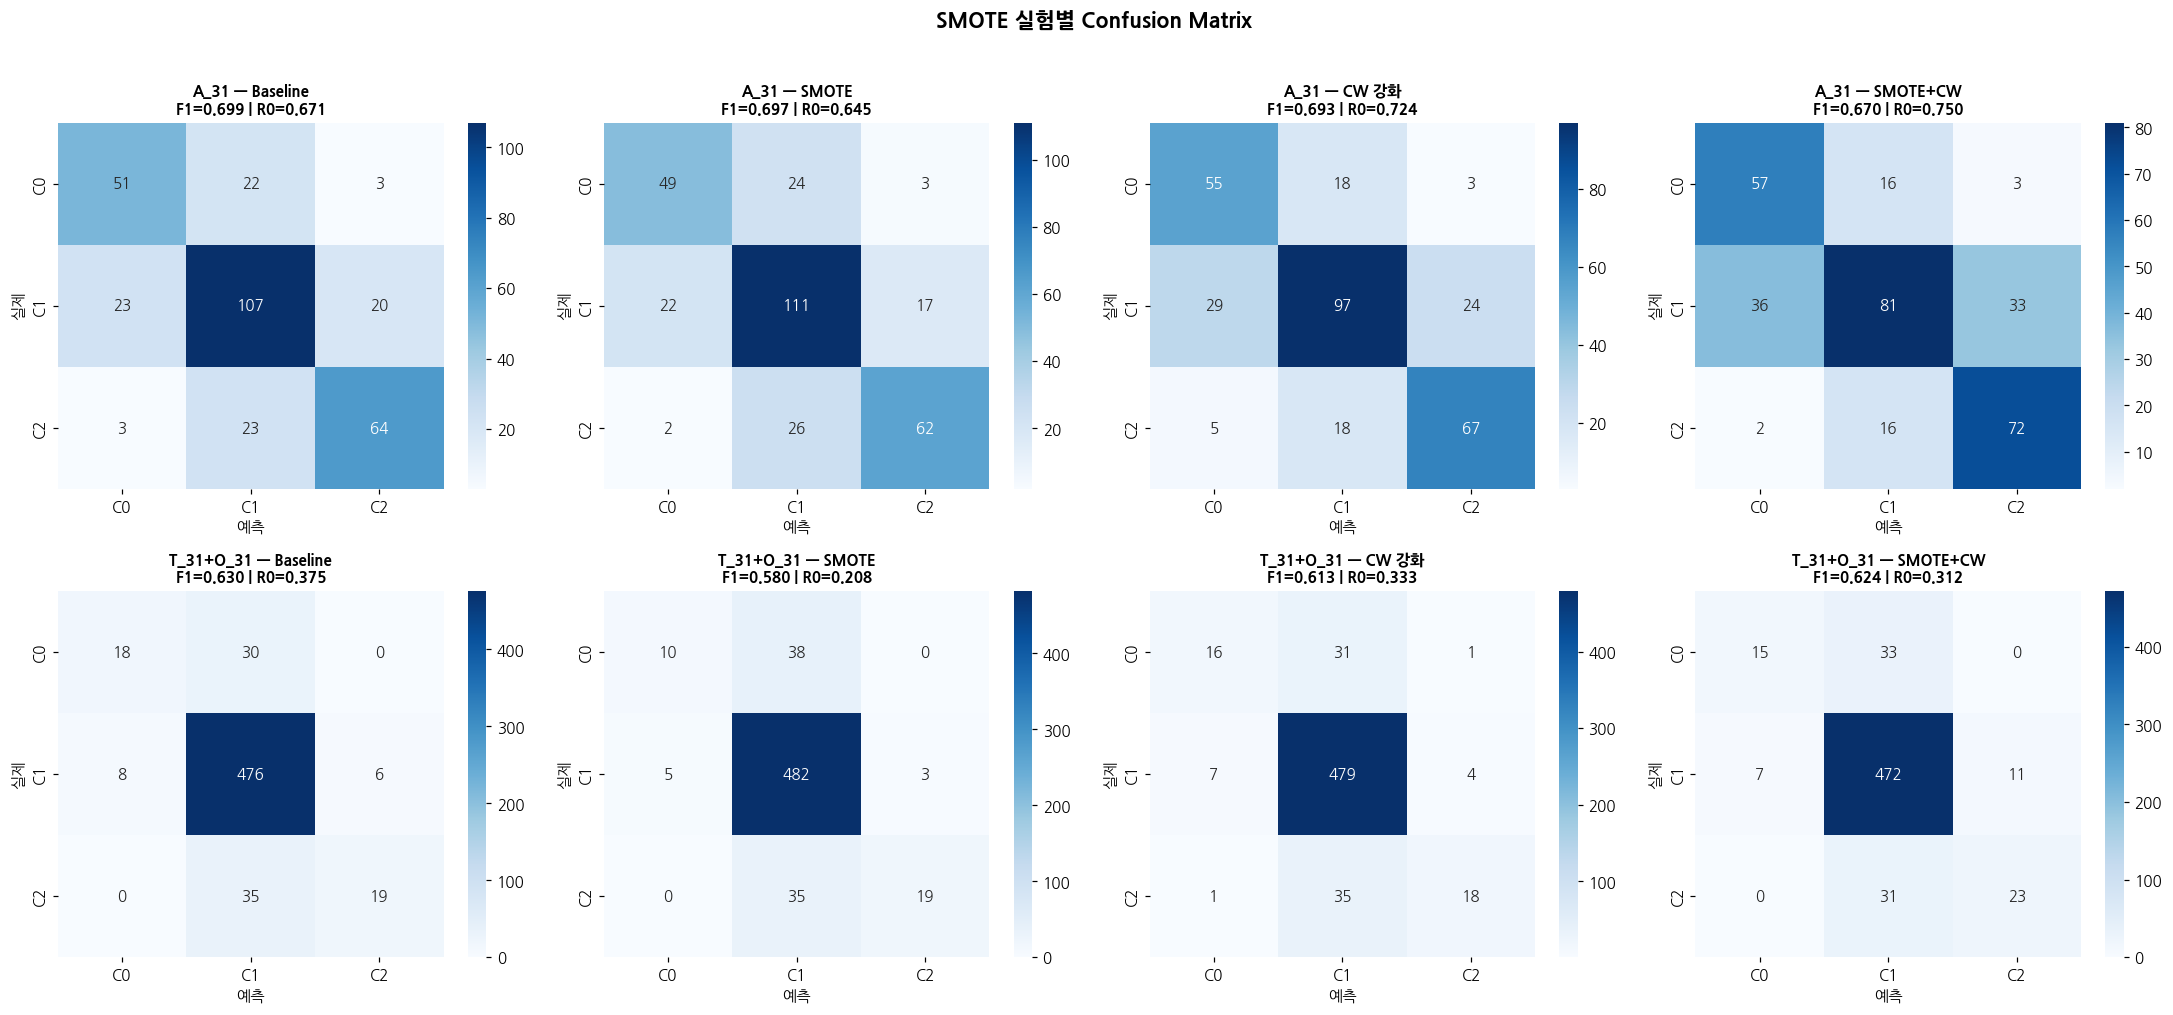

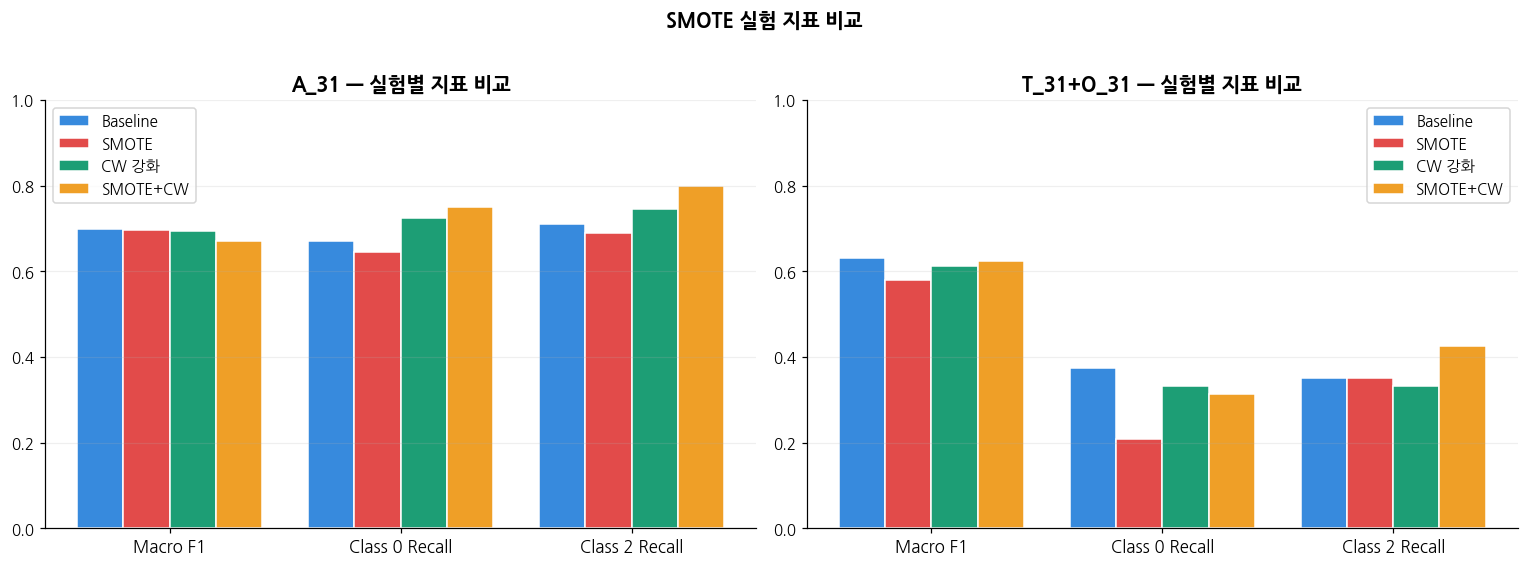

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
exp_names = ['Baseline', 'SMOTE', 'CW 강화', 'SMOTE+CW']

for row, (product, y, oofs) in enumerate([
    ('A_31', y_a, oofs_a),
    ('T_31+O_31', y_t, oofs_t)
]):
    for col, name in enumerate(exp_names):
        ax = axes[row, col]
        cm = confusion_matrix(y, oofs[name])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['C0','C1','C2'],
                    yticklabels=['C0','C1','C2'])
        s = results_a[name] if product == 'A_31' else results_t[name]
        ax.set_title(f'{product} — {name}\nF1={s["macro_f1"]:.3f} | R0={s["recall_0"]:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_ylabel('실제')
        ax.set_xlabel('예측')

plt.suptitle('SMOTE 실험별 Confusion Matrix', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 지표 비교 바 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['macro_f1', 'recall_0', 'recall_2']
metric_names = ['Macro F1', 'Class 0 Recall', 'Class 2 Recall']
colors = ['#378ADD', '#E24B4A', '#1D9E75', '#EF9F27']

for ax, (product, results) in zip(axes, [('A_31', results_a), ('T_31+O_31', results_t)]):
    x = np.arange(len(metrics))
    w = 0.2
    for i, (name, s) in enumerate(results.items()):
        vals = [s[m] for m in metrics]
        ax.bar(x + i*w, vals, w, label=name, color=colors[i], edgecolor='white')
    ax.set_xticks(x + w*1.5)
    ax.set_xticklabels(metric_names, fontsize=11)
    ax.set_title(f'{product} — 실험별 지표 비교', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('SMOTE 실험 지표 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. 인사이트 & 최종 전략 결정

In [7]:
print('=' * 55)
print('SMOTE 실험 인사이트')
print('=' * 55)

for product, results, baseline in [
    ('A_31', results_a, BASELINE['A_31']),
    ('T_31+O_31', results_t, BASELINE['T_31+O_31'])
]:
    best = max(results.items(), key=lambda x: x[1]['macro_f1'])
    best_r0 = max(results.items(), key=lambda x: x[1]['recall_0'])
    print(f'\n[{product}]')
    print(f'  Macro F1 최고: {best[0]} ({best[1]["macro_f1"]:.4f})')
    print(f'  Class 0 Recall 최고: {best_r0[0]} ({best_r0[1]["recall_0"]:.4f})')
    r0_improve = best_r0[1]['recall_0'] - baseline['recall_0']
    print(f'  Class 0 Recall 개선: {r0_improve:+.4f}')
    if r0_improve > 0.05:
        print(f'  -> SMOTE 효과 있음. {best_r0[0]} 전략 채택 권장')
    elif r0_improve > 0:
        print(f'  -> SMOTE 소폭 개선. 튜닝 병행 권장')
    else:
        print(f'  -> SMOTE 효과 미미. class_weight 조정 또는 피처 선택 우선')

print('\n' + '=' * 55)
print('다음 단계')
print('=' * 55)
print('  1. 최고 전략으로 Optuna 튜닝')
print('  2. Feature Importance 상위 피처만 선택 후 재학습')
print('  3. SHAP 분석 -> H1~H4 가설 검증')

SMOTE 실험 인사이트

[A_31]
  Macro F1 최고: Baseline (0.6995)
  Class 0 Recall 최고: SMOTE+CW (0.7500)
  Class 0 Recall 개선: +0.0789
  -> SMOTE 효과 있음. SMOTE+CW 전략 채택 권장

[T_31+O_31]
  Macro F1 최고: Baseline (0.6303)
  Class 0 Recall 최고: Baseline (0.3750)
  Class 0 Recall 개선: +0.0000
  -> SMOTE 효과 미미. class_weight 조정 또는 피처 선택 우선

다음 단계
  1. 최고 전략으로 Optuna 튜닝
  2. Feature Importance 상위 피처만 선택 후 재학습
  3. SHAP 분석 -> H1~H4 가설 검증
